In [3]:
import numpy as np
from parameters import get_parameters, get_slider_params, calculate_derived_parameters
from model_run import run_model_dash
from global_func import reset_flags, reset_E, reset_HSS, reset_S

# ANC phase

In [4]:
seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=100)
MODEL = {
    "int_period": 36,
    "n_months": 36,
}
slider_params = get_slider_params()
results = []

In [7]:
def find_min_runs(target_rse=0.01, max_runs=100, min_runs=10):
    """
    Determine the minimum number of runs needed for stable results across all target metrics.

    Args:
        target_tolerance: Maximum allowed relative standard error (e.g., 0.01 = 1%)
        max_runs: Maximum number of runs to test before giving up

    Returns:
        min_runs: Recommended minimum number of runs
        convergence_data: Dictionary tracking all metrics' convergence
    """
    # Initialize storage for convergence tracking
    metric_names = {
    "p_home_pre",
    "p_l23_pre",
    "p_l45_pre",
    }

    convergence_data = {k: {'values': [], 'means': [], 'stderrs': []}
                       for k in metric_names}

    seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=max_runs)
    MODEL = {"int_period": 36, "n_months": 36}
    slider_params = get_slider_params()

    for run in range(max_runs):
        # Run model (using your existing code structure)
        base_seed = seeds[run]
        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_param = calculate_derived_parameters(b_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S = reset_S(slider_params)
        b_E = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        _, outcomes,_ = run_model_dash(b_param, b_flags, MODEL["n_months"], MODEL["int_period"], base_seed=base_seed)

        # Calculate outcomes (your existing processing code)
        outcomes['i_loc_grouped'] = np.where(outcomes['i_loc'] == 0, 0,
                                           np.where(outcomes['i_loc'] == 1, 1, 2))

        # Store results for all target metrics
        run_results = {
        "p_home_pre": (outcomes['i_loc_grouped'] == 0).mean(),
        "p_l23_pre": (outcomes['i_loc_grouped'] == 1).mean(),
        "p_l45_pre": (outcomes['i_loc_grouped'] == 2).mean(),
        }

        # Update convergence tracking
        all_metrics_converged = (run + 1 >= min_runs)  # +1 because run starts at 0
        failed_metrics = []

        for metric in metric_names:
            value = run_results[metric]
            convergence_data[metric]['values'].append(value)
            n = len(convergence_data[metric]['values'])

            stderr = np.std(convergence_data[metric]['values'], ddof=1) / np.sqrt(n) if n > 1 else 0.0
            mean = np.mean(convergence_data[metric]['values'])

            convergence_data[metric]['means'].append(mean)
            convergence_data[metric]['stderrs'].append(stderr)

            if mean != 0:
                rel_stderr = abs(stderr / mean)
            else:
                rel_stderr = 0.0

            if rel_stderr > target_rse:
                all_metrics_converged = False

        if all_metrics_converged:
            print(f"\n✅ Convergence achieved at {run + 1} runs (all metrics ≤ {target_rse * 100:.0f}% RSE)")
            return run + 1, convergence_data

    print(f"\n⚠️ Warning: Convergence not achieved after {max_runs} runs.")
    return max_runs, convergence_data

min_runs, conv_data = find_min_runs(target_rse=0.05, max_runs=100, min_runs = 10)  # 5% tolerance


✅ Convergence achieved at 10 runs (all metrics ≤ 5% RSE)


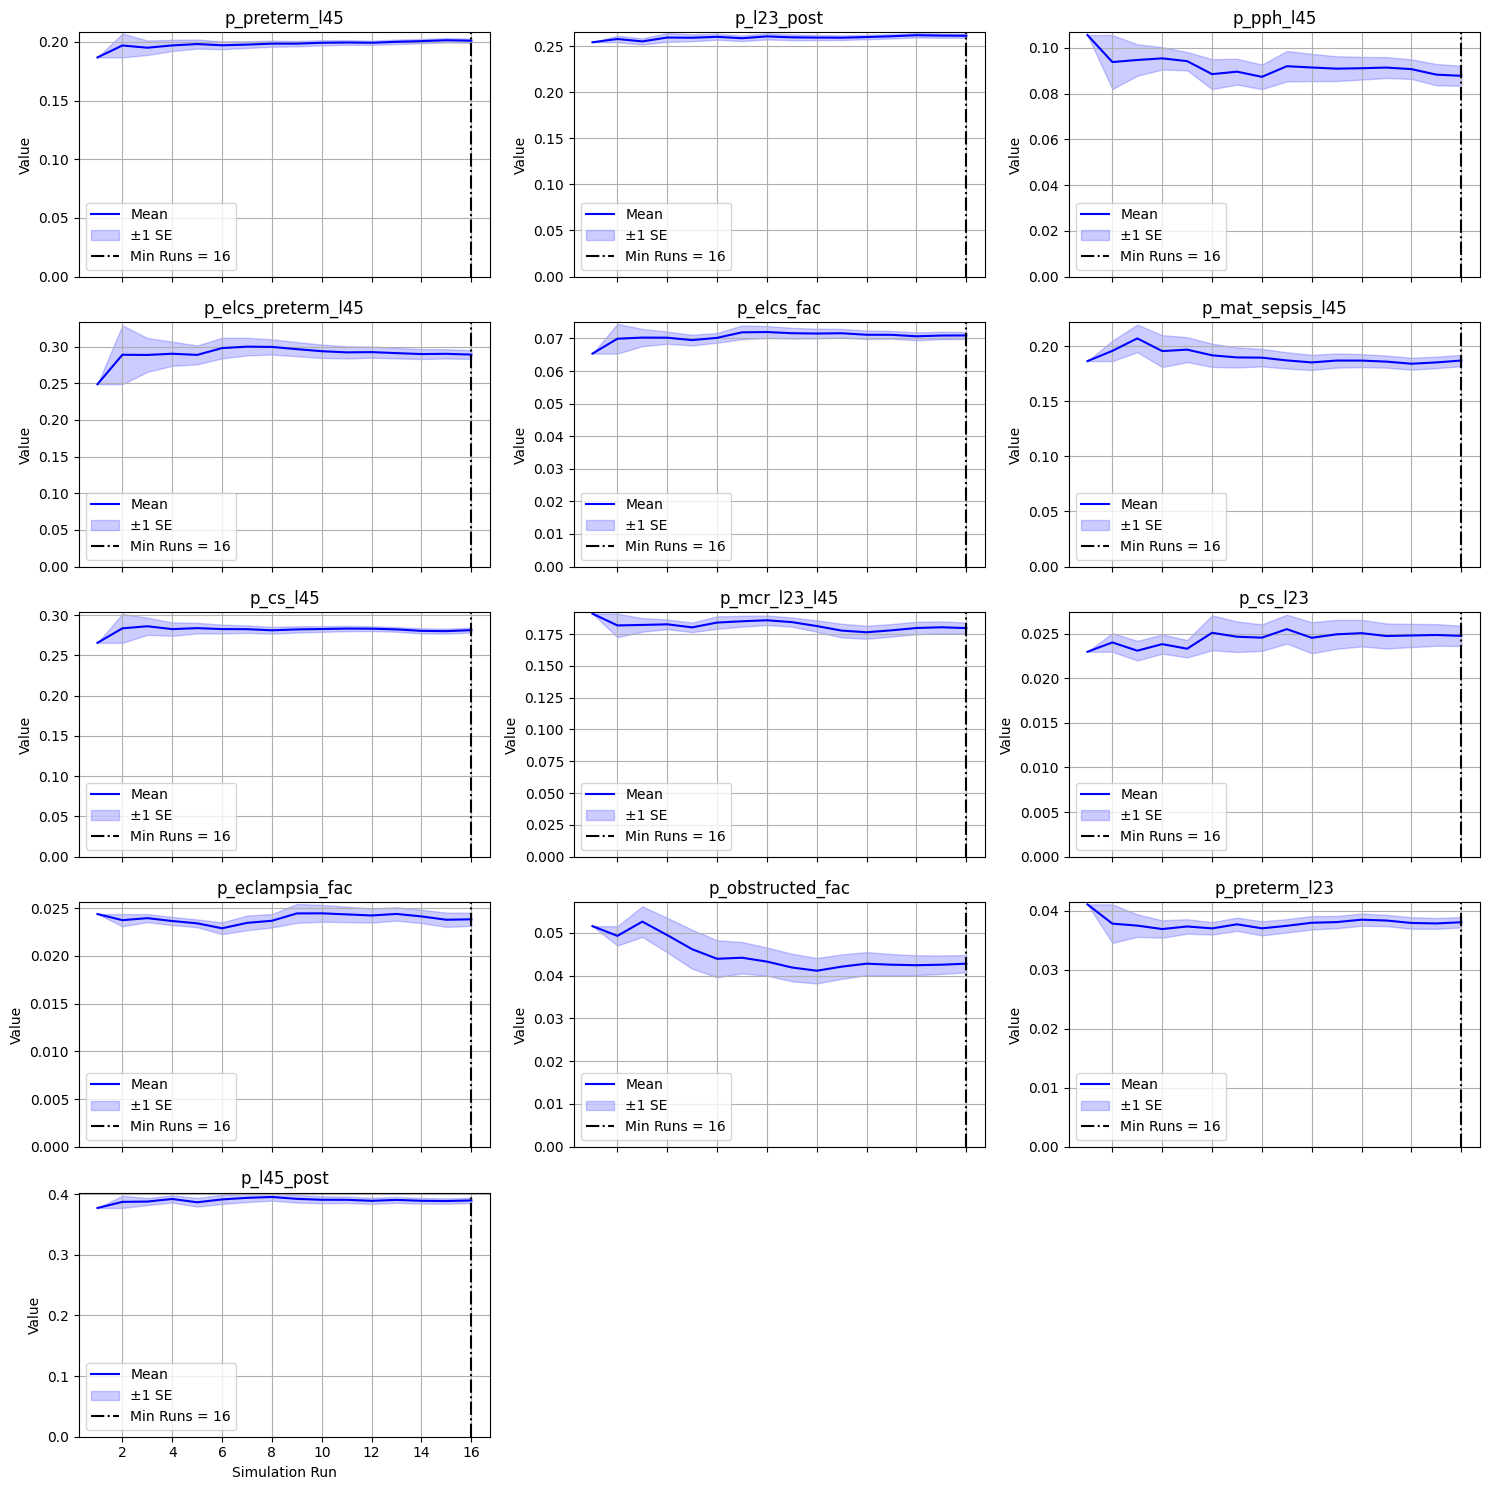

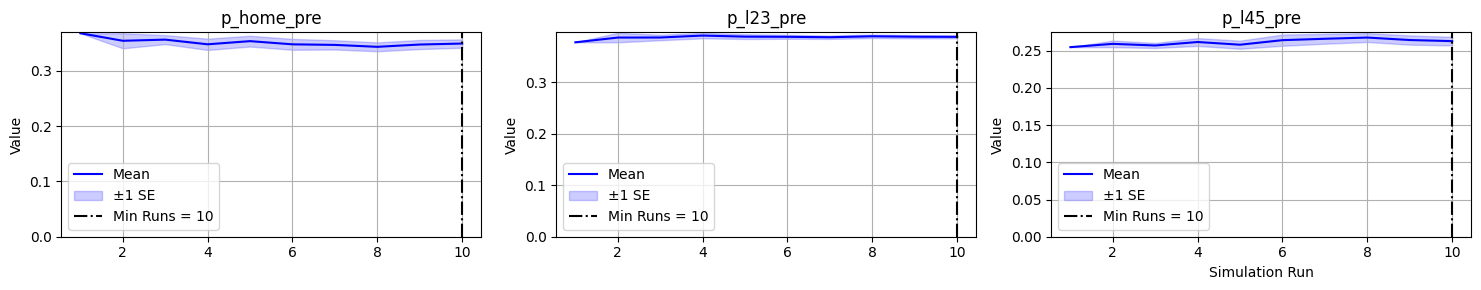

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

# Reorder conv_data to prioritize certain keys
order = ["p_home_pre", "p_l23_pre", "p_l45_pre"]  # your chosen order
extras = [k for k in conv_data if k not in order]
conv_data = {k: conv_data[k] for k in [*order, *extras]}

def plot_convergence_curves(convergence_data, min_runs, n_col=3):
    """
    Plot convergence curves in a grid with `n_col` columns.
    Each subplot shows mean and stderr bands over simulation runs.
    """
    n_metrics = len(convergence_data)
    n_row = math.ceil(n_metrics / n_col)

    fig, axs = plt.subplots(n_row, n_col, figsize=(5 * n_col, 3 * n_row), sharex=True)
    axs = axs.flatten()  # Flatten to 1D array for easy indexing

    for i, (metric, data) in enumerate(convergence_data.items()):
        ax = axs[i]
        runs = list(range(1, len(data['means']) + 1))
        means = data['means']
        stderrs = data['stderrs']

        ax.plot(runs, means, label='Mean', color='blue')
        ax.fill_between(runs,
                        [m - s for m, s in zip(means, stderrs)],
                        [m + s for m, s in zip(means, stderrs)],
                        color='blue', alpha=0.2, label='±1 SE')
        ax.axvline(min_runs, color='black', linestyle='-.', label=f'Min Runs = {min_runs}')
        ax.set_ylim(bottom=0)
        ax.set_title(metric)
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Add shared x-label to bottom-left plot (or last used plot)
    axs[min(i, len(axs) - 1)].set_xlabel('Simulation Run')

    plt.tight_layout()
    return fig

# Call the function and save the plot
fig = plot_convergence_curves(conv_data, min_runs, n_col=3)
fig.savefig("/Users/tingtingji/Documents/GitHub/SDR-Dashboard-2025/Calibration/MinimumRuns/ANC_runs.png", dpi=300)

# Labor and Delivery phase

In [5]:
def find_min_runs(target_rse=0.01, max_runs=100, min_runs=10):
    """
    Determine the minimum number of runs needed for stable results across all target metrics.

    Args:
        target_tolerance: Maximum allowed relative standard error (e.g., 0.01 = 1%)
        max_runs: Maximum number of runs to test before giving up

    Returns:
        min_runs: Recommended minimum number of runs
        convergence_data: Dictionary tracking all metrics' convergence
    """
    # Initialize storage for convergence tracking
    metric_names = {
    "p_elcs_fac",
    "p_elcs_preterm_l45",
    "p_preterm_l23",
    "p_preterm_l45",
    "p_cs_l23",

    "p_cs_l45",
    "p_l23_post",
    "p_l45_post",
    "p_mcr_l23_l45",

    "p_pph_l45",
    "p_mat_sepsis_l45",
    "p_eclampsia_fac",
    "p_obstructed_fac",
    }

    convergence_data = {k: {'values': [], 'means': [], 'stderrs': []}
                       for k in metric_names}

    seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=max_runs)
    MODEL = {"int_period": 36, "n_months": 36}
    slider_params = get_slider_params()

    for run in range(max_runs):
        # Run model (using your existing code structure)
        base_seed = seeds[run]
        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_param = calculate_derived_parameters(b_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S = reset_S(slider_params)
        b_E = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        _, outcomes,_ = run_model_dash(b_param, b_flags, MODEL["n_months"], MODEL["int_period"], base_seed=base_seed)

        # Calculate outcomes (your existing processing code)
        outcomes['i_CS'] = np.where(outcomes['i_mod'].isin(["EmCS", "ELCS"]), 1, 0)
        outcomes['i_loc_grouped'] = np.where(outcomes['i_loc_new_v2'] == 0, 0,
                                           np.where(outcomes['i_loc_new_v2'] == 1, 1, 2))
        outcomes['i_facility'] = np.where(outcomes['i_loc_new_v2'] > 0, 1, 0)
        mcr_l23_mean = np.nan_to_num(outcomes[outcomes['i_loc_grouped'] == 1]['i_comp_death_new'].mean(), nan=0.0)
        mcr_l45_mean = np.nan_to_num(outcomes[outcomes['i_loc_grouped'] == 2]['i_comp_death_new'].mean(), nan=0.0)
        p_mcr_l23_l45 = mcr_l23_mean / mcr_l45_mean if mcr_l45_mean != 0 else 0

        # Store results for all target metrics
        run_results = {
        "p_elcs_fac": outcomes.groupby('i_facility')['i_elec_CS'].mean().get(1, 0),
        "p_elcs_preterm_l45": outcomes[(outcomes['i_loc_grouped'] == 2) & (outcomes['i_preterm'] == 1)]['i_elec_CS'].mean(),
        "p_preterm_l23": outcomes[(outcomes['i_loc_grouped'] == 1)]['i_preterm'].mean(),
        "p_preterm_l45": outcomes[(outcomes['i_loc_grouped'] == 2)]['i_preterm'].mean(),
        "p_cs_l23": outcomes.groupby('i_loc_grouped')['i_CS'].mean().get(1, 0),

        "p_cs_l45": outcomes.groupby('i_loc_grouped')['i_CS'].mean().get(2, 0),
        "p_l23_post": (outcomes['i_loc_grouped'] == 1).mean(),
        "p_l45_post": (outcomes['i_loc_grouped'] == 2).mean(),
        "p_mcr_l23_l45": p_mcr_l23_l45,

        "p_pph_l45": outcomes.groupby('i_loc_grouped')['i_pph_new'].mean().get(2, 0),
        "p_mat_sepsis_l45": outcomes.groupby('i_loc_grouped')['i_mat_sepsis'].mean().get(2, 0),
        "p_eclampsia_fac": outcomes.groupby('i_facility')['i_eclampsia'].mean().get(1, 0),
        "p_obstructed_fac": outcomes.groupby('i_facility')['i_OL_final'].mean().get(1, 0),
        }

        # Update convergence tracking
        all_metrics_converged = (run + 1 >= min_runs)  # +1 because run starts at 0
        failed_metrics = []

        for metric in metric_names:
            value = run_results[metric]
            convergence_data[metric]['values'].append(value)
            n = len(convergence_data[metric]['values'])

            stderr = np.std(convergence_data[metric]['values'], ddof=1) / np.sqrt(n) if n > 1 else 0.0
            mean = np.mean(convergence_data[metric]['values'])

            convergence_data[metric]['means'].append(mean)
            convergence_data[metric]['stderrs'].append(stderr)

            if mean != 0:
                rel_stderr = abs(stderr / mean)
            else:
                rel_stderr = 0.0

            if rel_stderr > target_rse:
                all_metrics_converged = False

        if all_metrics_converged:
            print(f"\n✅ Convergence achieved at {run + 1} runs (all metrics ≤ {target_rse * 100:.0f}% RSE)")
            return run + 1, convergence_data

    print(f"\n⚠️ Warning: Convergence not achieved after {max_runs} runs.")
    return max_runs, convergence_data

min_runs, conv_data = find_min_runs(target_rse=0.05, max_runs=100, min_runs = 10)  # 5% tolerance


✅ Convergence achieved at 16 runs (all metrics ≤ 5% RSE)


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_convergence_curves(convergence_data, min_runs):
    """
    Plot convergence curves for each metric, showing mean and stderr bands over runs.
    Plots are arranged in a 3-column grid.
    """
    n_metrics = len(convergence_data)
    n_cols = 3
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), sharex=True)
    axs = axs.flatten()  # Flatten for easy indexing

    for i, (metric, data) in enumerate(convergence_data.items()):
        ax = axs[i]
        runs = list(range(1, len(data['means']) + 1))
        means = data['means']
        stderrs = data['stderrs']

        ax.plot(runs, means, label='Mean', color='blue')
        ax.fill_between(runs,
                        [m - s for m, s in zip(means, stderrs)],
                        [m + s for m, s in zip(means, stderrs)],
                        color='blue', alpha=0.2, label='±1 SE')

        ax.axvline(min_runs, color='black', linestyle='-.', label=f'Min Runs = {min_runs}')
        ax.set_ylim(bottom=0)
        ax.set_title(metric)
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    # Turn off any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    axs[min(i, len(axs)-1)].set_xlabel('Simulation Run')  # Add x-label to bottom-left plot

    plt.tight_layout()
    # Save figure

# Example usage:
plot_convergence_curves(conv_data, min_runs)
plt.savefig("/Users/tingtingji/Documents/GitHub/SDR-Dashboard-2025/Calibration/MinimumRuns/Labor_runs_5%error.png", dpi=300)

# Death phase

In [10]:
def find_min_runs(target_rse=0.1, max_runs=500, min_runs=10):
    """
    Determine the minimum number of simulation runs needed for stable outcomes
    based on convergence of relative standard error (RSE) over time.

    Args:
        target_rse: Maximum allowed relative standard error (e.g., 0.01 = 1%)
        max_runs: Maximum number of runs to test before giving up
        min_runs: Minimum number of runs required before checking for convergence

    Returns:
        min_runs: Recommended minimum number of runs
        convergence_data: Dictionary tracking all metrics' convergence (mean, stderr)
    """
    # Initialize metric names (no need for target values)
    metric_names = [
        "MMR_home", "MMR_l23", "MMR_l45",
        "p_death_aph", "p_death_pph", "p_death_eclampsia",
        "p_death_ol", "p_death_sepsis", "p_death_other"
    ]

    convergence_data = {k: {'values': [], 'means': [], 'stderrs': []} for k in metric_names}

    seeds = np.random.default_rng(2025).integers(low=0, high=1e6, size=max_runs)
    MODEL = {"int_period": 36, "n_months": 36}
    slider_params = get_slider_params()

    for run in range(max_runs):
        base_seed = seeds[run]
        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_param = calculate_derived_parameters(b_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S = reset_S(slider_params)
        b_E = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        _, outcomes,_ = run_model_dash(b_param, b_flags, MODEL["n_months"], MODEL["int_period"], base_seed=base_seed)

        outcomes['i_loc_grouped'] = np.where(outcomes['i_loc_new_v2'] == 0, 0,
                                             np.where(outcomes['i_loc_new_v2'] == 1, 1, 2))
        total_deaths = outcomes['i_mat_death'].sum()

        run_results = {
            "MMR_home": outcomes[(outcomes['i_loc_grouped'] == 0)]['i_mat_death'].mean() * 100000,
            "MMR_l23": outcomes[(outcomes['i_loc_grouped'] == 1)]['i_mat_death'].mean() * 100000,
            "MMR_l45": outcomes[(outcomes['i_loc_grouped'] == 2)]['i_mat_death'].mean() * 100000,
            "p_death_aph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "aph")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_pph": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "pph")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_eclampsia": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "eclampsia")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_ol": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "ol")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_sepsis": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "sepsis")).sum() / total_deaths if total_deaths > 0 else 0,
            "p_death_other": ((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "other")).sum() / total_deaths if total_deaths > 0 else 0,
        }

        all_metrics_converged = (run + 1 >= min_runs)
        for metric in metric_names:
            value = run_results[metric]
            convergence_data[metric]['values'].append(value)
            n = len(convergence_data[metric]['values'])

            stderr = np.std(convergence_data[metric]['values'], ddof=1) / np.sqrt(n) if n > 1 else 0.0
            mean = np.mean(convergence_data[metric]['values'])

            convergence_data[metric]['means'].append(mean)
            convergence_data[metric]['stderrs'].append(stderr)

            if mean != 0:
                rel_stderr = abs(stderr / mean)
            else:
                rel_stderr = 0.0

            if rel_stderr > target_rse:
                all_metrics_converged = False

        if all_metrics_converged:
            print(f"\n✅ Convergence achieved at {run + 1} runs (all metrics ≤ {target_rse * 100:.0f}% RSE)")
            return run + 1, convergence_data

    print(f"\n⚠️ Warning: Convergence not achieved after {max_runs} runs.")
    return max_runs, convergence_data

min_runs, conv_data = find_min_runs(target_rse=0.1, max_runs=500, min_runs=30)

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



✅ Convergence achieved at 337 runs (all metrics ≤ 10% RSE)


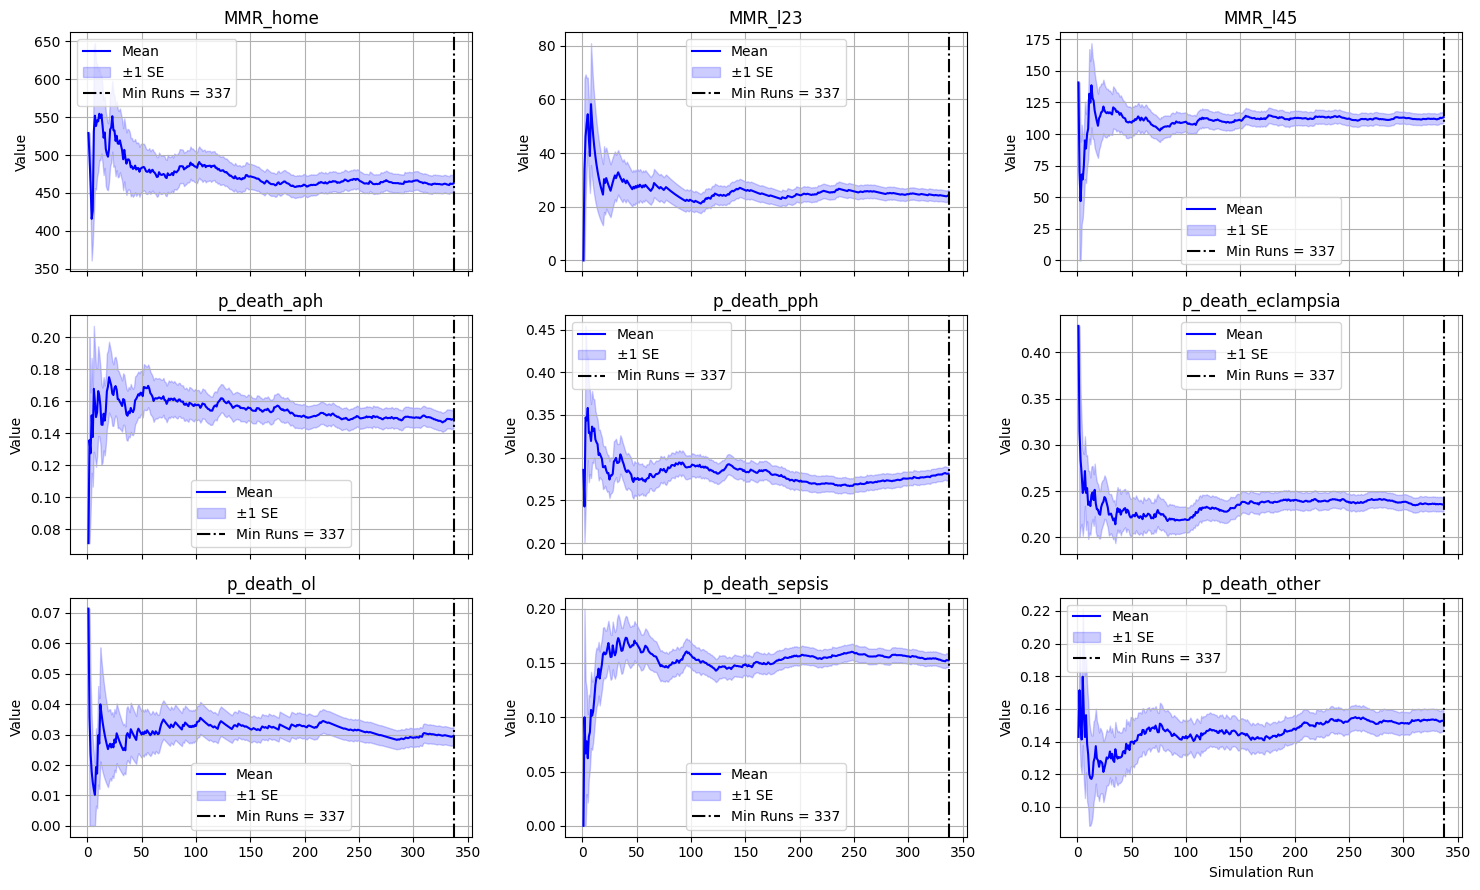

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_convergence_curves(convergence_data, min_runs, n_col=3):
    """
    Plot convergence curves in a grid with `n_col` columns.
    Each subplot shows mean and stderr bands over simulation runs.
    """
    n_metrics = len(convergence_data)
    n_row = math.ceil(n_metrics / n_col)

    fig, axs = plt.subplots(n_row, n_col, figsize=(5 * n_col, 3 * n_row), sharex=True)
    axs = axs.flatten()

    for i, (metric, data) in enumerate(convergence_data.items()):
        ax = axs[i]
        runs = list(range(1, len(data['means']) + 1))
        means = data['means']
        stderrs = data['stderrs']

        ax.plot(runs, means, label='Mean', color='blue')
        ax.fill_between(runs,
                        [m - s for m, s in zip(means, stderrs)],
                        [m + s for m, s in zip(means, stderrs)],
                        color='blue', alpha=0.2, label='±1 SE')
        ax.axvline(min_runs, color='black', linestyle='-.', label=f'Min Runs = {min_runs}')
        ax.set_title(metric)
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    # Remove unused axes if any
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Add x-label to the last used subplot
    axs[min(i, len(axs) - 1)].set_xlabel('Simulation Run')

    plt.tight_layout()
    return fig

# Plot and save
fig = plot_convergence_curves(conv_data, min_runs, n_col=3)
fig.savefig("/Users/tingtingji/Documents/GitHub/SDR-Dashboard-2025/Calibration/MinimumRuns/Death_runs_10pcterror.png", dpi=300)

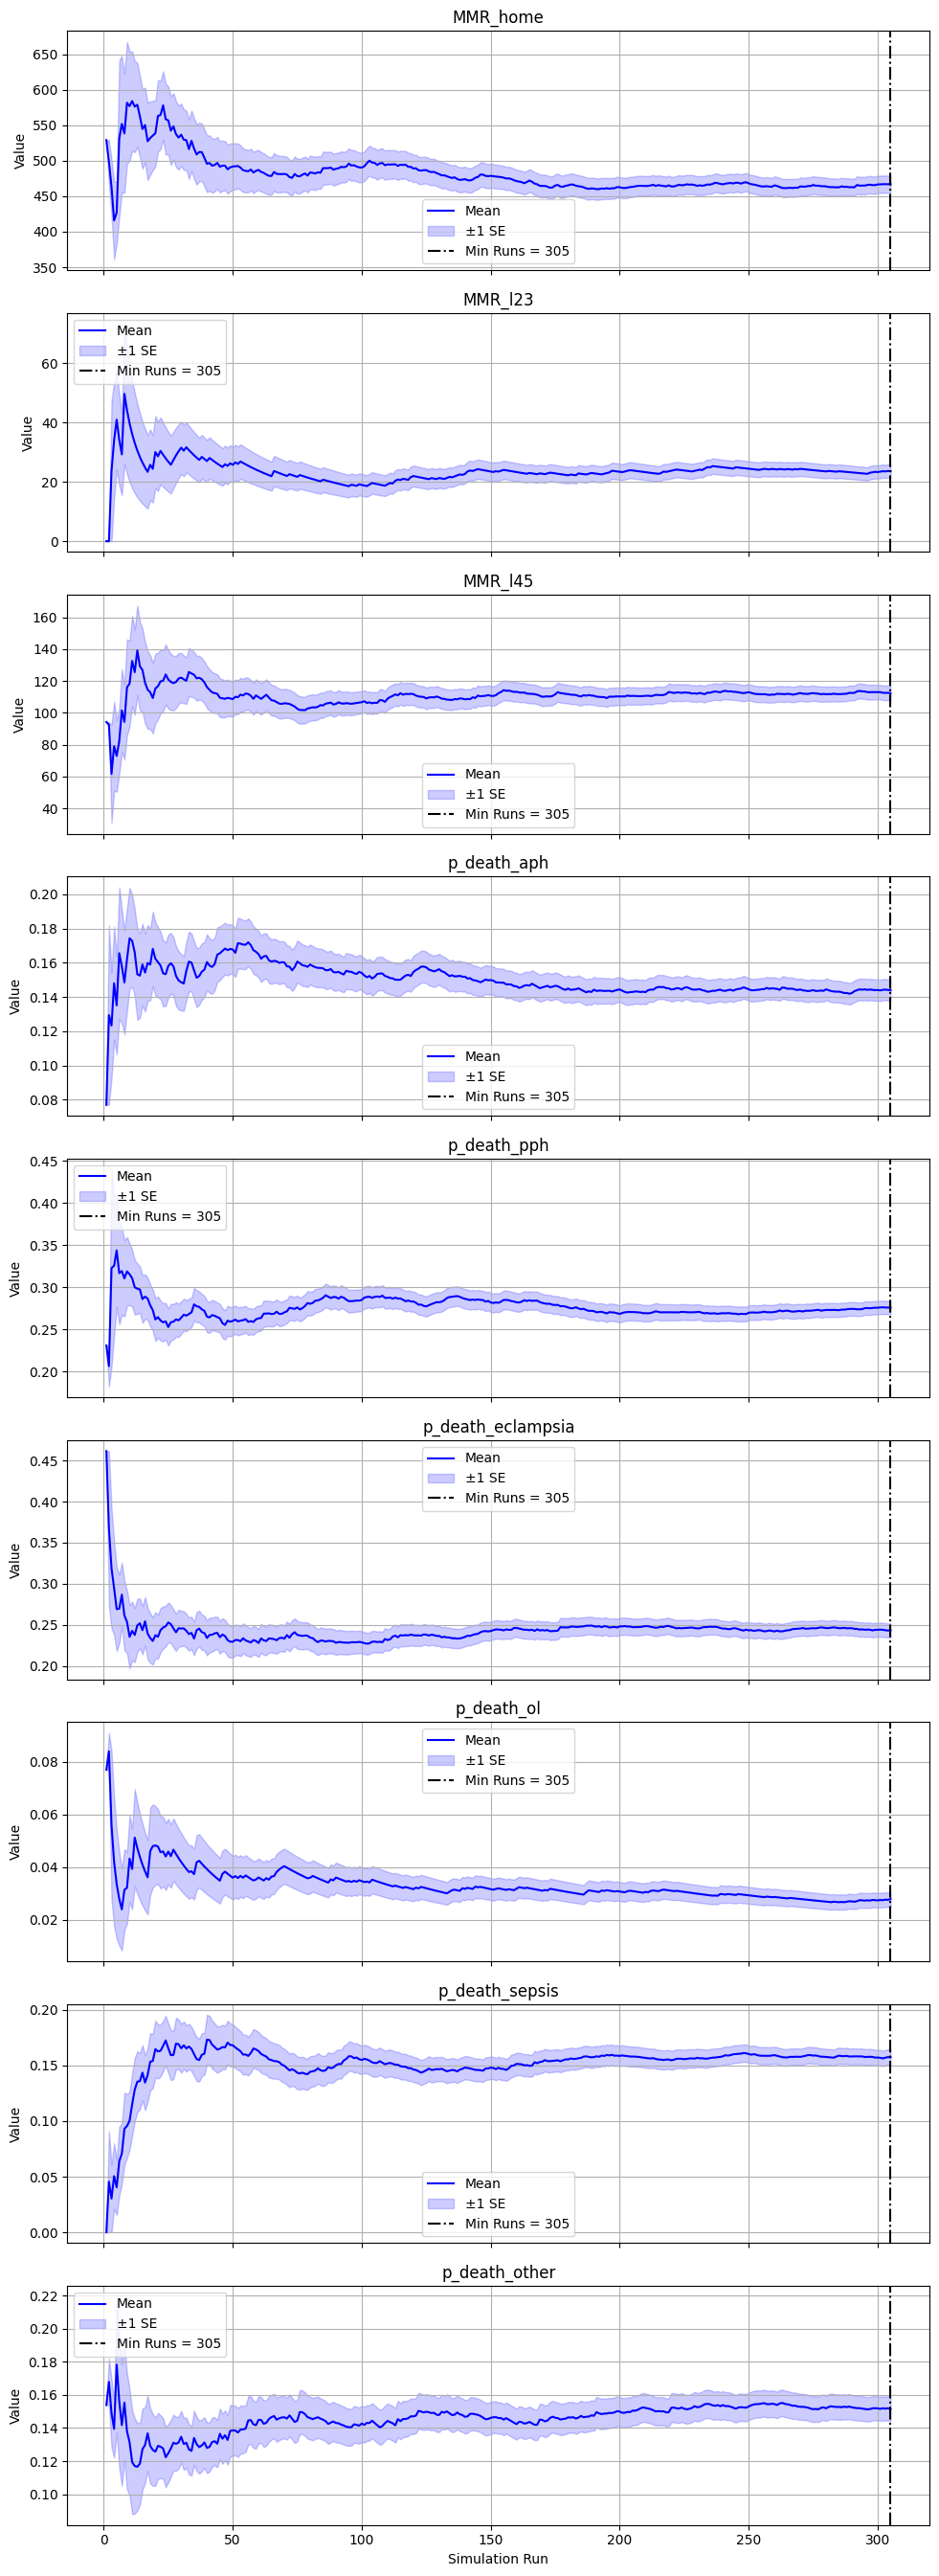

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence_curves(convergence_data, min_runs):
    """
    Plot convergence curves for each metric, showing mean and stderr bands over runs.
    """
    n_metrics = len(convergence_data)
    fig, axs = plt.subplots(n_metrics, 1, figsize=(10, 3 * n_metrics), sharex=True)

    if n_metrics == 1:
        axs = [axs]

    for ax, (metric, data) in zip(axs, convergence_data.items()):
        runs = list(range(1, len(data['means']) + 1))
        means = data['means']
        stderrs = data['stderrs']

        ax.plot(runs, means, label='Mean', color='blue')
        ax.fill_between(runs,
                        [m - s for m, s in zip(means, stderrs)],
                        [m + s for m, s in zip(means, stderrs)],
                        color='blue', alpha=0.2, label='±1 SE')

        ax.axvline(min_runs, color='black', linestyle='-.', label=f'Min Runs = {min_runs}')
        ax.set_title(metric)
        ax.set_ylabel('Value')
        ax.grid(True)
        ax.legend()

    axs[-1].set_xlabel('Simulation Run')
    plt.tight_layout()
    #plt.show()
plot_convergence_curves(conv_data, min_runs)
plt.savefig("/Users/tingtingji/Documents/GitHub/SDR-Dashboard-2025/Calibration/MinimumRuns/Death_runs_10pcterror.png", dpi=300)

In [10]:
import numpy as np
import random

def find_min_runs(
    target_rse=0.05,
    max_runs=500,
    min_runs=10,
    seed_base=2025,
    consecutive_k=10,
    per_metric_rse=None,
    batch_size=1,
    verbose=True,
):
    """
    Determine the minimum number of runs so that ALL metrics' RSE ≤ thresholds.
    Uses optional batching and requires `consecutive_k` consecutive passes.

    Parameters
    ----------
    target_rse : float
        Default RSE threshold for all metrics (overridden by per_metric_rse if given).
    max_runs : int
        Max single-run iterations (if batch_size>1, up to max_runs/batch_size batches).
    min_runs : int
        Minimum (raw) runs before checking convergence.
    seed_base : int
        Seed used to generate per-run seeds (reproducible).
    consecutive_k : int
        Require this many consecutive passes to declare convergence.
    per_metric_rse : dict or None
        Optional per-metric thresholds, e.g., {"MMR_home":0.10, ...}.
    batch_size : int
        If >1, aggregate `batch_size` raw runs into one batch mean before updating RSE.
    verbose : bool
        Print progress.

    Returns
    -------
    min_runs_effective : int
        Recommended minimum number of raw runs (not batches).
    convergence_data : dict
        For each metric: 'values' (batch means), 'means', 'stderrs', 'rses'.
    """

    metric_names = [
        "MMR_home", "MMR_l23", "MMR_l45",
        "p_death_aph", "p_death_pph", "p_death_eclampsia",
        "p_death_ol", "p_death_sepsis", "p_death_other"
    ]

    # per-metric thresholds
    if per_metric_rse is None:
        per_metric_rse = {m: target_rse for m in metric_names}

    conv = {m: {'values': [], 'means': [], 'stderrs': [], 'rses': []} for m in metric_names}

    seeds = np.random.default_rng(seed_base).integers(0, 1_000_000, size=max_runs)

    MODEL = {"int_period": 36, "n_months": 36}
    slider_params = get_slider_params()

    # batch accumulator
    batch_store = {m: [] for m in metric_names}
    consecutive_passes = 0

    def run_one(base_seed):
        # Seed both RNGs to be safe
        np.random.seed(int(base_seed))
        random.seed(int(base_seed))

        rng_param = np.random.default_rng(base_seed)
        b_param = get_parameters(rng=rng_param)
        b_param = calculate_derived_parameters(b_param)
        b_flags = reset_flags()
        b_HSS = reset_HSS(slider_params)
        b_S   = reset_S(slider_params)
        b_E   = reset_E()
        b_param.update({"E": b_E, "S": b_S, "HSS": b_HSS})

        _, outcomes, _ = run_model_dash(
            b_param, b_flags, MODEL["n_months"], MODEL["int_period"], base_seed=base_seed
        )

        outcomes['i_loc_grouped'] = np.where(
            outcomes['i_loc_new_v2'] == 0, 0,
            np.where(outcomes['i_loc_new_v2'] == 1, 1, 2)
        )

        total_deaths = int(outcomes['i_mat_death'].sum())

        # Optional Laplace smoothing to avoid all-zeros (comment out if undesired)
        smooth = 0.0  # e.g., try 0.5 for add-half smoothing

        res = {
            "MMR_home": outcomes[outcomes['i_loc_grouped'] == 0]['i_mat_death'].mean() * 100000,
            "MMR_l23":  outcomes[outcomes['i_loc_grouped'] == 1]['i_mat_death'].mean() * 100000,
            "MMR_l45":  outcomes[outcomes['i_loc_grouped'] == 2]['i_mat_death'].mean() * 100000,
            "p_death_aph":     (((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "aph")).sum() + smooth) / (total_deaths + 5*smooth) if total_deaths > 0 or smooth>0 else 0.0,
            "p_death_pph":     (((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "pph")).sum() + smooth) / (total_deaths + 5*smooth) if total_deaths > 0 or smooth>0 else 0.0,
            "p_death_eclampsia":(((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "eclampsia")).sum() + smooth) / (total_deaths + 5*smooth) if total_deaths > 0 or smooth>0 else 0.0,
            "p_death_ol":      (((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "ol")).sum() + smooth) / (total_deaths + 5*smooth) if total_deaths > 0 or smooth>0 else 0.0,
            "p_death_sepsis":  (((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "sepsis")).sum() + smooth) / (total_deaths + 5*smooth) if total_deaths > 0 or smooth>0 else 0.0,
            "p_death_other":   (((outcomes['i_mat_death'] == 1) & (outcomes["death_cause"] == "other")).sum() + smooth) / (total_deaths + 5*smooth) if total_deaths > 0 or smooth>0 else 0.0,
        }
        return res

    for i in range(max_runs):
        base_seed = seeds[i]
        res = run_one(base_seed)

        # accumulate into batches
        for m in metric_names:
            batch_store[m].append(res[m])

        # If not yet completed a batch, continue
        if ((i + 1) % batch_size) != 0:
            continue

        # finalize batch means and update convergence stats
        all_ok = True
        for m in metric_names:
            batch_mean = float(np.mean(batch_store[m]))
            batch_store[m].clear()  # reset for next batch

            vals = conv[m]['values']
            vals.append(batch_mean)

            n = len(vals)
            mean = float(np.mean(vals))
            std  = float(np.std(vals, ddof=1)) if n > 1 else 0.0
            se   = std / np.sqrt(n) if n > 0 else 0.0
            rse  = abs(se / mean) if mean != 0 else 0.0

            conv[m]['means'].append(mean)
            conv[m]['stderrs'].append(se)
            conv[m]['rses'].append(rse)

            if rse > per_metric_rse[m]:
                all_ok = False

        raw_runs_so_far = i + 1
        # Only start checking after min_runs
        if raw_runs_so_far >= min_runs and all_ok:
            consecutive_passes += 1
        else:
            consecutive_passes = 0

        if consecutive_passes >= consecutive_k:
            if verbose:
                print(f"\n✅ Convergence at {raw_runs_so_far} raw runs "
                      f"(batch_size={batch_size}, all metrics ≤ RSE thresholds "
                      f"for {consecutive_k} consecutive batches).")
            return raw_runs_so_far, conv

    if verbose:
        print(f"\n⚠️ Convergence not achieved after {max_runs} raw runs.")
    return max_runs, conv

min_runs, conv_data = find_min_runs(
    target_rse=0.1,
    max_runs=500,
    min_runs=30,
    seed_base=2025,
    consecutive_k=3,
    per_metric_rse=None,
    batch_size=10,
    verbose=True,
)

/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/tingtingji/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)



✅ Convergence at 400 raw runs (batch_size=10, all metrics ≤ RSE thresholds for 3 consecutive batches).
